# Lab 4: Data Visualization and EDA

#### CPE232 Data Models

---

1. Load all Superstore datasets.

*Note: The same datasets used in Lab 3*

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
import plotly.io as pio
pio.renderers.default = "png+notebook_connected+vscode"

In [2]:
# Write your code here
superstore_order = pd.read_csv('Superstore/superstore_order.csv')
superstore_people = pd.read_csv('Superstore/superstore_people.csv')
superstore_return = pd.read_csv('Superstore/superstore_return.csv')

2. Determine shape of each dataset (print out the results as well).

In [3]:
# Write your code here
print(superstore_order.shape)
print(superstore_people.shape)
print(superstore_return.shape)

(8880, 21)
(4, 2)
(296, 2)


3. Show information of the dataset.


In [4]:
# Write your code here
superstore_order.info()

<class 'pandas.DataFrame'>
RangeIndex: 8880 entries, 0 to 8879
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         8880 non-null   int64  
 1   Order ID       8880 non-null   str    
 2   Order Date     8880 non-null   str    
 3   Ship Date      8880 non-null   str    
 4   Ship Mode      8880 non-null   str    
 5   Customer ID    8880 non-null   str    
 6   Customer Name  8880 non-null   str    
 7   Segment        8880 non-null   str    
 8   Country        8880 non-null   str    
 9   City           8880 non-null   str    
 10  State          8880 non-null   str    
 11  Postal Code    8880 non-null   int64  
 12  Region         8880 non-null   str    
 13  Product ID     8880 non-null   str    
 14  Category       8880 non-null   str    
 15  Sub-Category   8880 non-null   str    
 16  Product Name   8880 non-null   str    
 17  Sales          8880 non-null   float64
 18  Quantity       8880

In [5]:
superstore_people.info()

<class 'pandas.DataFrame'>
RangeIndex: 4 entries, 0 to 3
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Person  4 non-null      str  
 1   Region  4 non-null      str  
dtypes: str(2)
memory usage: 196.0 bytes


In [6]:
superstore_return.info()

<class 'pandas.DataFrame'>
RangeIndex: 296 entries, 0 to 295
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   Returned  296 non-null    str  
 1   Order ID  296 non-null    str  
dtypes: str(2)
memory usage: 4.8 KB


4. Are there any missing values? If so, in which column?

Ans: There are no missing values in any column

5.
- 5.1 List unique segments
- 5.2 List unique segments and their corresponding count
- 5.3 Create a pie chart to demonstrate unique segments and their count
- 5.4 Briefly describe what could be interpreted from this pie chart

*Note: please create additional cells to answer 5.2 - 5.3*

In [7]:
# Write your code here (5.1)
uq_segment = superstore_order["Segment"].unique()
uq_segment

<StringArray>
['Consumer', 'Corporate', 'Home Office']
Length: 3, dtype: str

In [8]:
superstore_order["Segment"].value_counts()

Segment
Consumer       4613
Corporate      2673
Home Office    1594
Name: count, dtype: int64

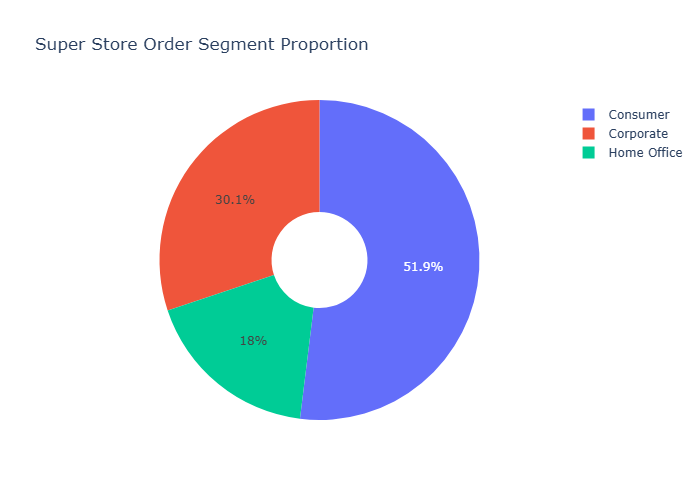

In [9]:
fig = px.pie(superstore_order, names='Segment', title='Super Store Order Segment Proportion', hole=0.3)
fig.show()


Answer for the question 5.4

Ans: The Consumer segment is the largest and accounts for more than half of the total orders.

6.
- 6.1 List unique states
- 6.2 List top-10 unique states and their corresponding count
- 6.3 Create a bar chart (vertical) to demonstrate the count of top-10 unique states
- 6.4 Based on 6.2, also include the total sales of these states (show your result as a dataframe)
- 6.5 Using the result from 6.4, if you were the owner of this superstore, what information could be interpreted from this result?

*Note: please create additional cells to answer 6.2 - 6.4*

In [10]:
# Write your code here (6.1)
superstore_order["State"].unique()

<StringArray>
[            'Kentucky',           'California',              'Florida',
       'North Carolina',           'Washington',                'Texas',
            'Wisconsin',                 'Utah',             'Nebraska',
         'Pennsylvania',             'Illinois',            'Minnesota',
             'Michigan',             'Delaware',              'Indiana',
             'New York',              'Arizona',             'Virginia',
            'Tennessee',              'Alabama',       'South Carolina',
               'Oregon',             'Colorado',                 'Iowa',
                 'Ohio',             'Missouri',             'Oklahoma',
           'New Mexico',            'Louisiana',          'Connecticut',
           'New Jersey',        'Massachusetts',              'Georgia',
               'Nevada',         'Rhode Island',          'Mississippi',
             'Arkansas',              'Montana',        'New Hampshire',
             'Maryland', 'District of

In [11]:
top_state = superstore_order["State"].value_counts().head(10).reset_index()
top_state

,State,count
0,California,1754
1,New York,1001
2,Texas,860
3,Pennsylvania,531
4,Washington,452
5,Illinois,427
6,Ohio,396
7,Florida,339
8,Michigan,230
9,North Carolina,229


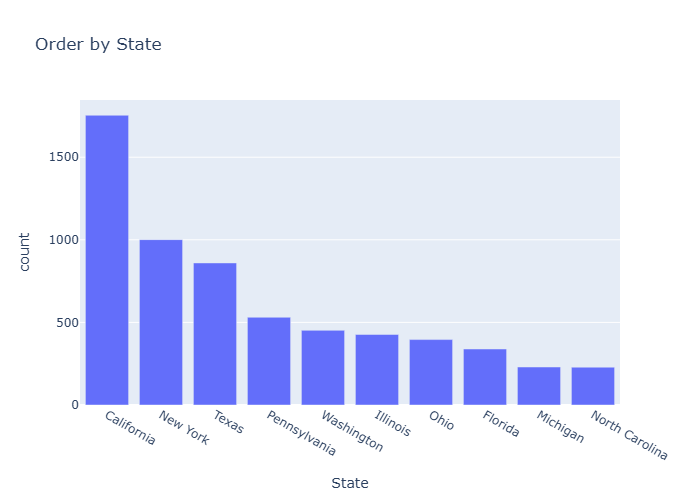

In [12]:
px.bar(top_state,x = "State", y = "count", title="Order by State")

Answer for the question 6.5

Ans: There are only 4 State that have orders more than 500 orders.

7.
- 7.1 List unique categories
- 7.2 Create a bar chart (horizontal) to demonstrate the proportion of these categories
- 7.3 Compute the ratio of these categories in percentage and print the results

*Note: please create additional cells to answer 7.2 - 7.3*

In [13]:
# Write your code here (7.1)
superstore_order["Category"].unique()

<StringArray>
['Furniture', 'Office Supplies', 'Technology']
Length: 3, dtype: str

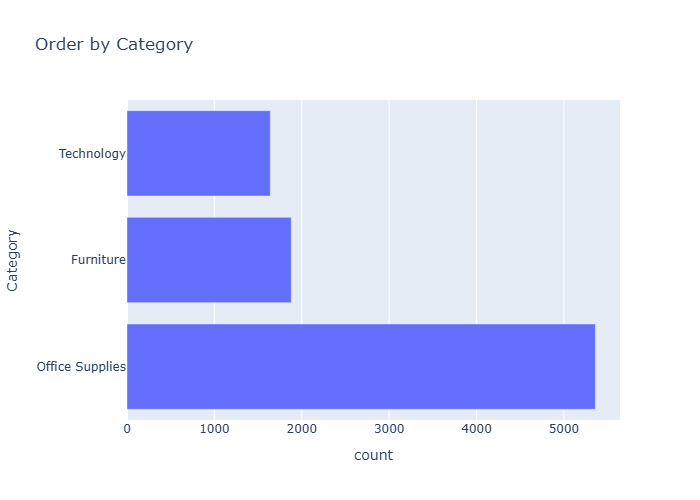

In [14]:
cat_count = superstore_order["Category"].value_counts().reset_index()
fig = px.bar(cat_count,x="count",y = "Category",title = "Order by Category",orientation="h")
fig.show()

In [15]:
order_count = cat_count["count"].sum()
Technology_ratio = cat_count[cat_count["Category"] == "Technology"]["count"].item() / order_count
Furniture_ratio = cat_count[cat_count["Category"] == "Furniture"]["count"].item() / order_count
Office_Supplies_ratio = cat_count[cat_count["Category"] == "Office Supplies"]["count"].item() / order_count
print(f"Technology_ratio {Technology_ratio:.2%}")
print(f"Furniture_ratio {Furniture_ratio:.2%}")
print(f"Office_Supplies_ratio {Office_Supplies_ratio:.2%}")

Technology_ratio 18.47%
Furniture_ratio 21.17%
Office_Supplies_ratio 60.36%


8. Update the type of all columns that contain dates to *datetime* and show information after an update.

In [16]:
# write your code here
superstore_order["Order Date"] = pd.to_datetime(superstore_order["Order Date"], format="%d/%m/%Y")
superstore_order["Ship Date"] = pd.to_datetime(superstore_order["Ship Date"], format="%d/%m/%Y")
superstore_order.info()

<class 'pandas.DataFrame'>
RangeIndex: 8880 entries, 0 to 8879
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         8880 non-null   int64         
 1   Order ID       8880 non-null   str           
 2   Order Date     8880 non-null   datetime64[us]
 3   Ship Date      8880 non-null   datetime64[us]
 4   Ship Mode      8880 non-null   str           
 5   Customer ID    8880 non-null   str           
 6   Customer Name  8880 non-null   str           
 7   Segment        8880 non-null   str           
 8   Country        8880 non-null   str           
 9   City           8880 non-null   str           
 10  State          8880 non-null   str           
 11  Postal Code    8880 non-null   int64         
 12  Region         8880 non-null   str           
 13  Product ID     8880 non-null   str           
 14  Category       8880 non-null   str           
 15  Sub-Category   8880 non-null   s

9. Create a new column "Processing time day" to show number of days taken to ship an order and show your result in a dataframe format.

*Hint: The duration starts as soon as the item has been ordered and ends once the order has successfully shipped.*

In [17]:
# write your code here
superstore_order["Processing time day"] = superstore_order["Ship Date"] - superstore_order["Order Date"]
superstore_order["Processing time day"]

0      3 days
1      3 days
2      4 days
3      7 days
4      7 days
        ...  
8875   6 days
8876   6 days
8877   6 days
8878   6 days
8879   2 days
Name: Processing time day, Length: 8880, dtype: timedelta64[us]

10. Based on the result in 9.
- 10.1 How many orders are there that take more than 5 days to process?
- 10.2 Show the top 5 rows (expected output should contain these columns: Order ID, Order Date, Ship Date, Processing time day, Quantity)
- 10.3 Plot the histogram based on the column Quantity

*Note: please create additional cells to answer 10.2 - 10.3*

In [18]:
# Write your code here (10.1)
(superstore_order["Processing time day"].dt.days > 5).sum()

np.int64(1656)

In [19]:
superstore_order.loc[:4,["Order ID","Order Date","Ship Date","Processing time day","Quantity"]]

,Order ID,Order Date,Ship Date,Processing time day,Quantity
0,CA-2016-152156,2016-11-08,2016-11-11,3 days,2
1,CA-2016-152156,2016-11-08,2016-11-11,3 days,3
2,CA-2016-138688,2016-06-12,2016-06-16,4 days,2
3,US-2015-108966,2015-10-11,2015-10-18,7 days,5
4,US-2015-108966,2015-10-11,2015-10-18,7 days,2


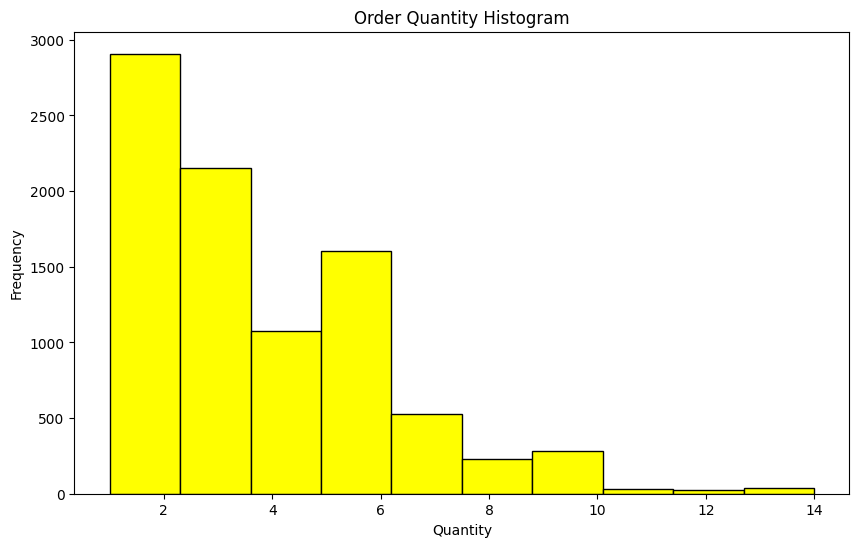

In [20]:
plt.figure(figsize=(10, 6))
plt.hist(superstore_order['Quantity'], bins=10, color='yellow', edgecolor='black')
plt.title("Order Quantity Histogram")
plt.xlabel('Quantity')
plt.ylabel('Frequency')
plt.show()

11. Total sales compare across different regions
  
- 11.1 Create a bar chart to visualize.

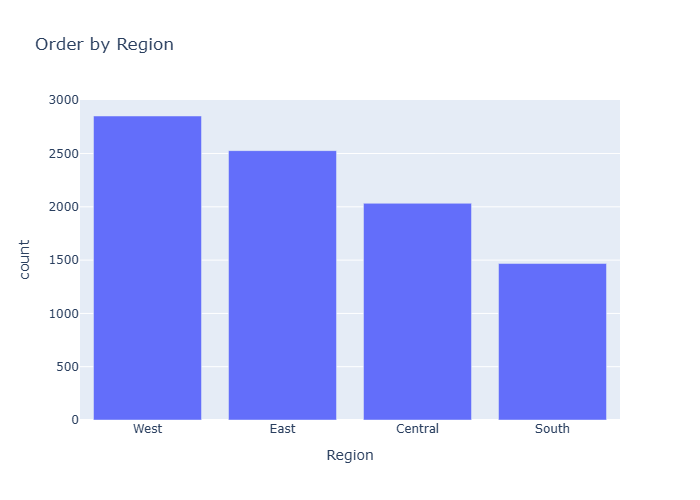

In [21]:
# Write your code here (11.1)
reg_count = superstore_order["Region"].value_counts().reset_index()
px.bar(reg_count,x = "Region", y = "count", title="Order by Region")

- 11.2 How do total sales compare across different regions? Explain in as much detail as possible.
  
  Ans: South region is only region that order less than 2000 orders while West and East have order more than 2500 orders.

12.Which states have the highest number of returns? Use a horizontal bar chart.

Ans: California

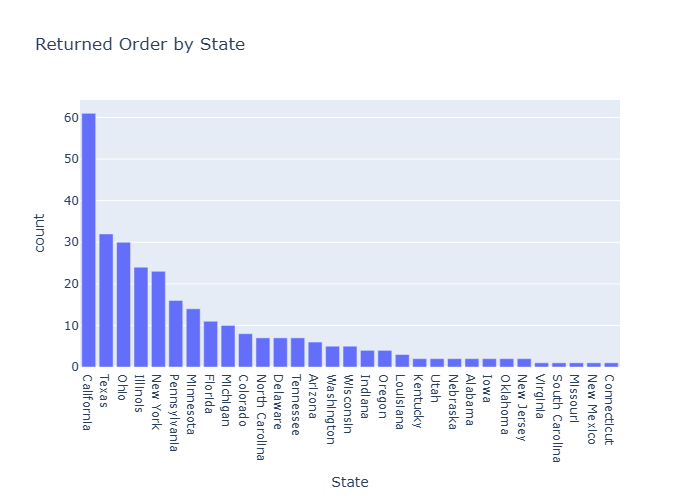

In [22]:
# Write your code here (12)
returned_order = pd.concat([superstore_order, superstore_return], axis=1, join='inner')
returned_order_count_by_state = returned_order["State"].value_counts().reset_index()
px.bar(returned_order_count_by_state,x = "State", y = "count", title="Returned Order by State")

13. What is the correlation between numerical variables in the superstore_order dataset? Use a heatmap
*Hint: Use seaborn to create a heatmap :)*

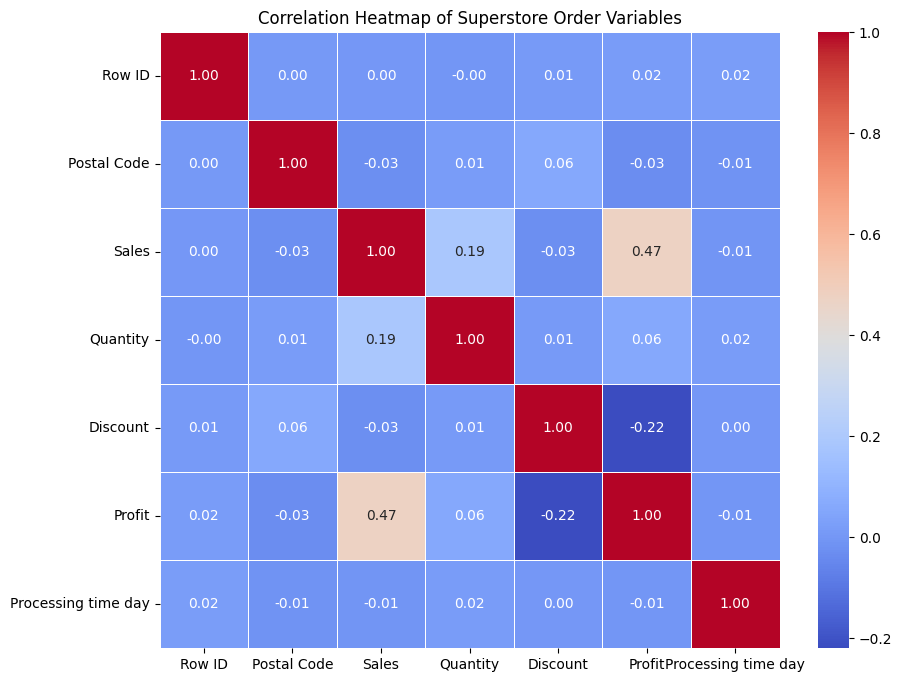

In [23]:
# Write your code here (13)
numeric_superstore = superstore_order.select_dtypes(include=['number'])
correlation_matrix = numeric_superstore.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap of Superstore Order Variables')
plt.show()

14. Create a USA State-Level Choropleth Map to visualize total sales per state.

*   The darkest color represents the highest total sales.
*   The lightest color represents the lowest total sales.
*   Use a continuous gradient scale (e.g., dark blue to light blue, dark red to light red, or any custom gradient of your choice).

*Hint: Use plotly.express*

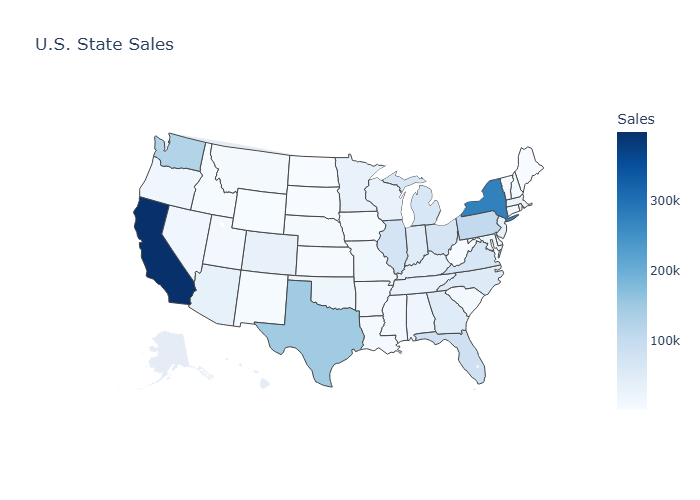

In [24]:
# Write your code here (14)
state_sales = superstore_order.groupby("State")["Sales"].sum().reset_index()

state_map = {
    'Alabama': 'AL', 'Alaska': 'AK', 'Arizona': 'AZ', 'Arkansas': 'AR', 'California': 'CA',
    'Colorado': 'CO', 'Connecticut': 'CT', 'Delaware': 'DE', 'Florida': 'FL', 'Georgia': 'GA',
    'Hawaii': 'HI', 'Idaho': 'ID', 'Illinois': 'IL', 'Indiana': 'IN', 'Iowa': 'IA',
    'Kansas': 'KS', 'Kentucky': 'KY', 'Louisiana': 'LA', 'Maine': 'ME', 'Maryland': 'MD',
    'Massachusetts': 'MA', 'Michigan': 'MI', 'Minnesota': 'MN', 'Mississippi': 'MS',
    'Missouri': 'MO', 'Montana': 'MT', 'Nebraska': 'NE', 'Nevada': 'NV', 'New Hampshire': 'NH',
    'New Jersey': 'NJ', 'New Mexico': 'NM', 'New York': 'NY', 'North Carolina': 'NC',
    'North Dakota': 'ND', 'Ohio': 'OH', 'Oklahoma': 'OK', 'Oregon': 'OR', 'Pennsylvania': 'PA',
    'Rhode Island': 'RI', 'South Carolina': 'SC', 'South Dakota': 'SD', 'Tennessee': 'TN',
    'Texas': 'TX', 'Utah': 'UT', 'Vermont': 'VT', 'Virginia': 'VA', 'Washington': 'WA',
    'West Virginia': 'WV', 'Wisconsin': 'WI', 'Wyoming': 'WY', 'District of Columbia': 'DC'
}

state_sales['State Code'] = state_sales['State'].map(state_map)

fig = px.choropleth(
    state_sales,
    locations='State Code',
    locationmode='USA-states',
    color='Sales',
    hover_name='State',
    color_continuous_scale='Blues',
    scope='usa',
    title='U.S. State Sales'
)
fig.show()

  14.2 Answer the following questions:
1.   Which state has the highest total sales?
2.   How do sales anomalies affect the gradient color shading on the map?
3.   If you change the color scale, does it impact readability? Why or why not?

Ans:


1.   California
2.   gradient Scale of anomalies are compute as darkest or lightest while other is on similar gradient lead to challenges for analyzing.
3.   Changing color sclae impact readablity, a sequential scale is ideal for showing ordered, low-to-high data. A diverging scale is better for highlighting extremes or a significant value.



15. Create a box plot to compare the different shipping modes based on total profit.

In [25]:
#Write your code here (15)
superstore_order["Ship Mode"].unique()

<StringArray>
['Second Class', 'Standard Class', 'First Class', 'Same Day']
Length: 4, dtype: str

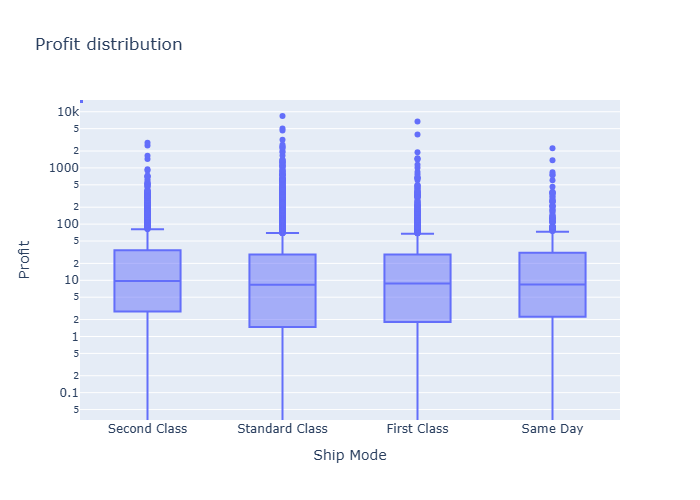

In [33]:
fig = px.box(superstore_order,x="Ship Mode",y="Profit",title="Profit distribution",log_y=True)
fig.show()

15.2 Which shipping mode has the highest median profit?

Ans: Second Class

[BONUS 20 pts] Determine the percentage of customers who:
- B1)returned the product once
- B2) returned the product at least once
- B3) never returned the product
- Finally, Plot a comparison of B2 and B3

*Note: please create additional cells to answer the above points*

In [27]:
# B1
customor_count = len(superstore_order["Customer ID"].unique())
concated_return = pd.concat([superstore_order, superstore_return], axis=1, join='inner') 
return_count = concated_return["Customer ID"].value_counts()
once_return = (return_count == 1).sum()
B1 = once_return/customor_count
print(f"B1 = {B1:.2%}")

B1 = 7.10%


In [28]:
# B2
return_count = concated_return["Customer ID"].value_counts()
B2 = (return_count.sum())/customor_count
print(f"B2 = {B2:.2%}")

B2 = 37.52%


In [29]:
# B3
B3 = (customor_count - return_count.sum())/customor_count
print(f"B3 = {B3:.2%}")

B3 = 62.48%


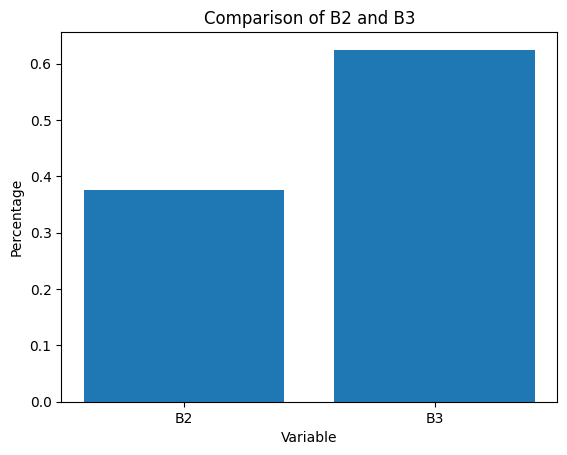

In [30]:
labels = ['B2', 'B3']
percentage = [B2, B3]
plt.bar(labels, percentage)
plt.title('Comparison of B2 and B3')
plt.xlabel('Variable')
plt.ylabel('Percentage')
plt.show()